In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/INM/ML_Feb26/housingData.csv')
data

,house_area,house_price,bedrooms,lift,city,floor
0,1262.881245,38.156437,3bhk,NaN,Hyd,third
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first
4,1078.882497,33.886475,1bhk,0.0,Blr,ground
...,...,...,...,...,...,...
995,1019.644332,32.719330,1bhk,NaN,Pune,second
996,1153.063719,34.981912,NaN,NaN,Pune,second
997,1255.712846,38.081385,3bhk,NaN,Pune,first
998,1240.645962,39.179379,3bhk,NaN,Hyd,second


In [ ]:
df=data.copy()

In [ ]:
## drop null rows from house_area and house_price

In [ ]:
df.dropna(subset=['house_area','house_price'],inplace=True)
df.shape

(994, 6)

In [ ]:
df

,house_area,house_price,bedrooms,lift,city,floor
0,1262.881245,38.156437,3bhk,NaN,Hyd,third
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first
4,1078.882497,33.886475,1bhk,0.0,Blr,ground
...,...,...,...,...,...,...
995,1019.644332,32.719330,1bhk,NaN,Pune,second
996,1153.063719,34.981912,NaN,NaN,Pune,second
997,1255.712846,38.081385,3bhk,NaN,Pune,first
998,1240.645962,39.179379,3bhk,NaN,Hyd,second


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
cols = df[['house_area','house_price']]
cols

,house_area,house_price
0,1262.881245,38.156437
1,1143.840962,35.415229
2,1362.809667,42.734290
3,1215.430502,38.252915
4,1078.882497,33.886475
...,...,...
995,1019.644332,32.719330
996,1153.063719,34.981912
997,1255.712846,38.081385
998,1240.645962,39.179379


In [ ]:
scaler=StandardScaler()

In [ ]:
# this computes mean and std dev for all the given columns
scaler.fit(cols)

StandardScaler()

In [ ]:
scaler.get_params()

{'copy': True, 'with_mean': True, 'with_std': True}

In [ ]:
# mean of both columns
scaler.mean_

array([1199.58245266,   37.46017982])

In [ ]:
#std dev of both columns
scaler.scale_

array([102.23246166,   3.53536371])

In [ ]:
scaled_cols = scaler.transform(cols)
scaled_cols

array([[ 0.61916529,  0.19694085],
       [-0.54524258, -0.57842732],
       [ 1.59662804,  1.49181545],
       ...,
       [ 0.54904668,  0.17571193],
       [ 0.40166801,  0.48628633],
       [-0.66299387, -0.78240638]])

In [ ]:
scaled_cols.shape

(994, 2)

In [ ]:
scaled_cols[:,0].shape

(994,)

In [ ]:
df['scaled_area']=scaled_cols[:,0]
df['scaled_price']=scaled_cols[:,1]
df

,house_area,house_price,bedrooms,lift,city,floor,scaled_area,scaled_price
0,1262.881245,38.156437,3bhk,NaN,Hyd,third,0.619165,0.196941
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground,-0.545243,-0.578427
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground,1.596628,1.491815
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first,0.155020,0.224230
4,1078.882497,33.886475,1bhk,0.0,Blr,ground,-1.180642,-1.010845
...,...,...,...,...,...,...,...,...
995,1019.644332,32.719330,1bhk,NaN,Pune,second,-1.760088,-1.340979
996,1153.063719,34.981912,NaN,NaN,Pune,second,-0.455029,-0.700994
997,1255.712846,38.081385,3bhk,NaN,Pune,first,0.549047,0.175712
998,1240.645962,39.179379,3bhk,NaN,Hyd,second,0.401668,0.486286


<Axes: xlabel='scaled_area', ylabel='Density'>

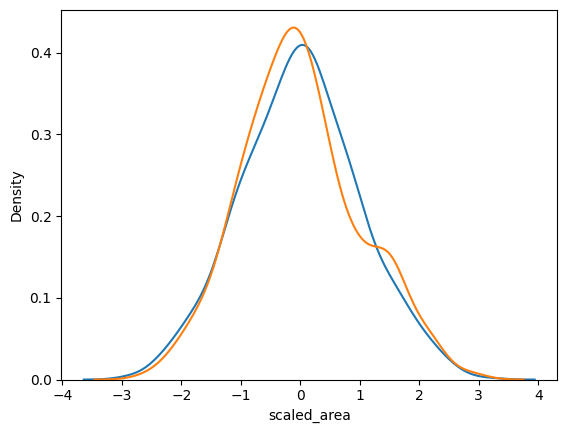

In [ ]:
sns.kdeplot(df['scaled_area'])
sns.kdeplot(df['scaled_price'])

In [ ]:
## fit and transform could be done together

scaler=StandardScaler()

scaled_cols = scaler.fit_transform(cols)
scaled_cols

array([[ 0.61916529,  0.19694085],
       [-0.54524258, -0.57842732],
       [ 1.59662804,  1.49181545],
       ...,
       [ 0.54904668,  0.17571193],
       [ 0.40166801,  0.48628633],
       [-0.66299387, -0.78240638]])

## Feature Encoding

## One hot encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
encoded_city = encoder.fit_transform(df[['city']])
encoded_city

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]])

In [ ]:
encoded_city

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 994 stored elements and shape (994, 4)>

In [ ]:
new_cols = list(encoder.categories_[0])
new_cols

['Blr', 'Hyd', 'Mumbai', 'Pune']

In [ ]:
df.loc[:,new_cols] = encoded_city

In [ ]:
df

,house_area,house_price,bedrooms,lift,city,floor,scaled_area,scaled_price,Blr,Hyd,Mumbai,Pune
0,1262.881245,38.156437,3bhk,NaN,Hyd,third,0.619165,0.196941,0.0,1.0,0.0,0.0
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground,-0.545243,-0.578427,0.0,0.0,1.0,0.0
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground,1.596628,1.491815,0.0,0.0,1.0,0.0
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first,0.155020,0.224230,0.0,0.0,1.0,0.0
4,1078.882497,33.886475,1bhk,0.0,Blr,ground,-1.180642,-1.010845,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1019.644332,32.719330,1bhk,NaN,Pune,second,-1.760088,-1.340979,0.0,0.0,0.0,1.0
996,1153.063719,34.981912,NaN,NaN,Pune,second,-0.455029,-0.700994,0.0,0.0,0.0,1.0
997,1255.712846,38.081385,3bhk,NaN,Pune,first,0.549047,0.175712,0.0,0.0,0.0,1.0
998,1240.645962,39.179379,3bhk,NaN,Hyd,second,0.401668,0.486286,0.0,1.0,0.0,0.0


## Label Encoding

In [ ]:
df

,house_area,house_price,bedrooms,lift,city,floor,scaled_area,scaled_price,Blr,Hyd,Mumbai,Pune
0,1262.881245,38.156437,3bhk,NaN,Hyd,third,0.619165,0.196941,0.0,1.0,0.0,0.0
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground,-0.545243,-0.578427,0.0,0.0,1.0,0.0
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground,1.596628,1.491815,0.0,0.0,1.0,0.0
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first,0.155020,0.224230,0.0,0.0,1.0,0.0
4,1078.882497,33.886475,1bhk,0.0,Blr,ground,-1.180642,-1.010845,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1019.644332,32.719330,1bhk,NaN,Pune,second,-1.760088,-1.340979,0.0,0.0,0.0,1.0
996,1153.063719,34.981912,NaN,NaN,Pune,second,-0.455029,-0.700994,0.0,0.0,0.0,1.0
997,1255.712846,38.081385,3bhk,NaN,Pune,first,0.549047,0.175712,0.0,0.0,0.0,1.0
998,1240.645962,39.179379,3bhk,NaN,Hyd,second,0.401668,0.486286,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

encoded_floor = encoder.fit_transform(df['floor'])

encoded_floor.shape

(994,)

In [ ]:
encoder.classes_

array(['first', 'ground', 'second', 'third'], dtype=object)

In [ ]:
label_encoder = {'ground':0,'first':1,'second':2,'third':3}
label_encoder

{'ground': 0, 'first': 1, 'second': 2, 'third': 3}

In [ ]:
df['encoded_floor'] = df['floor'].apply(lambda x:label_encoder[x])
df

,house_area,house_price,bedrooms,lift,city,floor,scaled_area,scaled_price,Blr,Hyd,Mumbai,Pune,encoded_floor
0,1262.881245,38.156437,3bhk,NaN,Hyd,third,0.619165,0.196941,0.0,1.0,0.0,0.0,3
1,1143.840962,35.415229,2bhk,0.0,Mumbai,ground,-0.545243,-0.578427,0.0,0.0,1.0,0.0,0
2,1362.809667,42.734290,3bhk,0.0,Mumbai,ground,1.596628,1.491815,0.0,0.0,1.0,0.0,0
3,1215.430502,38.252915,2bhk,NaN,Mumbai,first,0.155020,0.224230,0.0,0.0,1.0,0.0,1
4,1078.882497,33.886475,1bhk,0.0,Blr,ground,-1.180642,-1.010845,1.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1019.644332,32.719330,1bhk,NaN,Pune,second,-1.760088,-1.340979,0.0,0.0,0.0,1.0,2
996,1153.063719,34.981912,NaN,NaN,Pune,second,-0.455029,-0.700994,0.0,0.0,0.0,1.0,2
997,1255.712846,38.081385,3bhk,NaN,Pune,first,0.549047,0.175712,0.0,0.0,0.0,1.0,1
998,1240.645962,39.179379,3bhk,NaN,Hyd,second,0.401668,0.486286,0.0,1.0,0.0,0.0,2


In [ ]:
## for ML training, we'll use the scaled and encoded columns
## Raw columns will not be used in next step of ML training

## Text Data Preprocessing

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/INM/ML Mar 25/ML_L28_IMDB_Dataset.csv')
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [ ]:
df=data[:1000].copy()
df.shape

(1000, 2)

## Lower case the text

In [ ]:
df['review']=df['review'].apply(lambda x:x.lower())
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive
...,...,...
995,nothing is sacred. just ask ernie fosselius. t...,positive
996,i hated it. i hate self-aware pretentious inan...,negative
997,i usually try to be professional and construct...,negative
998,if you like me is going to see this in a film ...,negative


## Special Character Removal
- remove all special chars like -> , . ? ! " ~ `

In [ ]:
import re #regex-> used for string preprocessing
df['review_without_punc']=df['review'].apply(lambda x:re.sub('[^a-zA-Z0-9]',' ',x))
df

,review,sentiment,review_without_punc
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production br br the...
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is...",positive,petter mattei s love in the time of money is...
...,...,...,...
995,nothing is sacred. just ask ernie fosselius. t...,positive,nothing is sacred just ask ernie fosselius t...
996,i hated it. i hate self-aware pretentious inan...,negative,i hated it i hate self aware pretentious inan...
997,i usually try to be professional and construct...,negative,i usually try to be professional and construct...
998,if you like me is going to see this in a film ...,negative,if you like me is going to see this in a film ...


## Tokenization

In [ ]:
df['tokenized'] = df['review_without_punc'].apply(lambda x:x.split())
df

,review,sentiment,review_without_punc,tokenized
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production br br the...,"[a, wonderful, little, production, br, br, the..."
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"[basically, there, s, a, family, where, a, lit..."
4,"petter mattei's ""love in the time of money"" is...",positive,petter mattei s love in the time of money is...,"[petter, mattei, s, love, in, the, time, of, m..."
...,...,...,...,...
995,nothing is sacred. just ask ernie fosselius. t...,positive,nothing is sacred just ask ernie fosselius t...,"[nothing, is, sacred, just, ask, ernie, fossel..."
996,i hated it. i hate self-aware pretentious inan...,negative,i hated it i hate self aware pretentious inan...,"[i, hated, it, i, hate, self, aware, pretentio..."
997,i usually try to be professional and construct...,negative,i usually try to be professional and construct...,"[i, usually, try, to, be, professional, and, c..."
998,if you like me is going to see this in a film ...,negative,if you like me is going to see this in a film ...,"[if, you, like, me, is, going, to, see, this, ..."


## Stop words removal

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
stopwords_list = stopwords.words('english')

In [ ]:
len(stopwords_list)

198

In [ ]:
def remove_stopwords(tokens_list):
  clean_tokens = []
  for t in tokens_list:
    if not t in set(stopwords_list):
      clean_tokens.append(t)
  return clean_tokens

In [ ]:
sample=['i','am','working','on','ml']
remove_stopwords(sample)

['working', 'ml']

In [ ]:
df['clean_tokens']=df['tokenized'].apply(lambda x:remove_stopwords(x))
df

,review,sentiment,review_without_punc,tokenized,clean_tokens
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e..."
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production br br the...,"[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su..."
3,basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"[basically, there, s, a, family, where, a, lit...","[basically, family, little, boy, jake, thinks,..."
4,"petter mattei's ""love in the time of money"" is...",positive,petter mattei s love in the time of money is...,"[petter, mattei, s, love, in, the, time, of, m...","[petter, mattei, love, time, money, visually, ..."
...,...,...,...,...,...
995,nothing is sacred. just ask ernie fosselius. t...,positive,nothing is sacred just ask ernie fosselius t...,"[nothing, is, sacred, just, ask, ernie, fossel...","[nothing, sacred, ask, ernie, fosselius, days,..."
996,i hated it. i hate self-aware pretentious inan...,negative,i hated it i hate self aware pretentious inan...,"[i, hated, it, i, hate, self, aware, pretentio...","[hated, hate, self, aware, pretentious, inanit..."
997,i usually try to be professional and construct...,negative,i usually try to be professional and construct...,"[i, usually, try, to, be, professional, and, c...","[usually, try, professional, constructive, cri..."
998,if you like me is going to see this in a film ...,negative,if you like me is going to see this in a film ...,"[if, you, like, me, is, going, to, see, this, ...","[like, going, see, film, history, class, somet..."


## Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
# eg - Basic Lemmatization
words = ['running','education','boys','feet','educated','really','rainy']

lemm_words = [lemmatizer.lemmatize(w) for w in words]
lemm_words

['running', 'education', 'boy', 'foot', 'educated', 'really', 'rainy']

In [ ]:
# Lemmatization with part-of-speech tag

from nltk.corpus import wordnet
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
pos_tags = pos_tag(words)
pos_tags

[('running', 'VBG'),
 ('education', 'NN'),
 ('boys', 'VBZ'),
 ('feet', 'NNS'),
 ('educated', 'VBD'),
 ('really', 'RB'),
 ('rainy', 'JJ')]

In [ ]:
## convert nltk pos to wordnet pos
def get_wordnet_pos(nltk_pos_tag):
  if nltk_pos_tag.startswith('J'):
    return wordnet.ADJ
  elif nltk_pos_tag.startswith('V'):
    return wordnet.VERB
  elif nltk_pos_tag.startswith('N'):
    return wordnet.NOUN
  elif nltk_pos_tag.startswith('R'):
    return wordnet.ADV
  else:
    return wordnet.NOUN


lemma_words = [lemmatizer.lemmatize(word,get_wordnet_pos(pos_tag)) for word,pos_tag in pos_tags]
lemma_words

['run', 'education', 'boys', 'foot', 'educate', 'really', 'rainy']

## Stemming

In [ ]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

stem_words = [ps.stem(w) for w in words]
stem_words


def stem_tokens(tokens):
  stemmed = [ps.stem(w) for w in tokens]
  return stemmed

In [ ]:
# we'll go with stemming of words
df['stem_tokens'] = df['clean_tokens'].apply(lambda x:stem_tokens(x))
df

,review,sentiment,review_without_punc,tokenized,clean_tokens,stem_tokens
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, h..."
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production br br the...,"[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin...","[wonder, littl, product, br, br, film, techniq..."
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe..."
3,basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"[basically, there, s, a, family, where, a, lit...","[basically, family, little, boy, jake, thinks,...","[basic, famili, littl, boy, jake, think, zombi..."
4,"petter mattei's ""love in the time of money"" is...",positive,petter mattei s love in the time of money is...,"[petter, mattei, s, love, in, the, time, of, m...","[petter, mattei, love, time, money, visually, ...","[petter, mattei, love, time, money, visual, st..."
...,...,...,...,...,...,...
995,nothing is sacred. just ask ernie fosselius. t...,positive,nothing is sacred just ask ernie fosselius t...,"[nothing, is, sacred, just, ask, ernie, fossel...","[nothing, sacred, ask, ernie, fosselius, days,...","[noth, sacr, ask, erni, fosseliu, day, everybo..."
996,i hated it. i hate self-aware pretentious inan...,negative,i hated it i hate self aware pretentious inan...,"[i, hated, it, i, hate, self, aware, pretentio...","[hated, hate, self, aware, pretentious, inanit...","[hate, hate, self, awar, pretenti, inan, masqu..."
997,i usually try to be professional and construct...,negative,i usually try to be professional and construct...,"[i, usually, try, to, be, professional, and, c...","[usually, try, professional, constructive, cri...","[usual, tri, profession, construct, critic, mo..."
998,if you like me is going to see this in a film ...,negative,if you like me is going to see this in a film ...,"[if, you, like, me, is, going, to, see, this, ...","[like, going, see, film, history, class, somet...","[like, go, see, film, histori, class, someth, ..."


In [ ]:
print(df['clean_tokens'][0])

['one', 'reviewers', 'mentioned', 'watching', '1', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened', 'br', 'br', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches', 'regards', 'drugs', 'sex', 'violence', 'hardcore', 'classic', 'use', 'word', 'br', 'br', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focuses', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cells', 'glass', 'fronts', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'many', 'aryans', 'muslims', 'gangstas', 'latinos', 'christians', 'italians', 'irish', 'scuffles', 'death', 'stares', 'dodgy', 'dealings', 'shady', 'agreements', 'never', 'far', 'away', 'br', 'br', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goes', 'shows', 'dare', 'forget', 'pretty', 'pictures', 'painted', 'mainstre

In [ ]:
print(df['stem_tokens'][0])

['one', 'review', 'mention', 'watch', '1', 'oz', 'episod', 'hook', 'right', 'exactli', 'happen', 'br', 'br', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'heart', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violenc', 'hardcor', 'classic', 'use', 'word', 'br', 'br', 'call', 'oz', 'nicknam', 'given', 'oswald', 'maximum', 'secur', 'state', 'penitentari', 'focus', 'mainli', 'emerald', 'citi', 'experiment', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inward', 'privaci', 'high', 'agenda', 'em', 'citi', 'home', 'mani', 'aryan', 'muslim', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'scuffl', 'death', 'stare', 'dodgi', 'deal', 'shadi', 'agreement', 'never', 'far', 'away', 'br', 'br', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goe', 'show', 'dare', 'forget', 'pretti', 'pictur', 'paint', 'mainstream', 'audienc', 'forget', 'charm', 'forget', 'romanc', 'oz', 'm

In [ ]:
print(df['tokenized'][100])

['this', 'short', 'film', 'that', 'inspired', 'the', 'soon', 'to', 'be', 'full', 'length', 'feature', 'spatula', 'madness', 'is', 'a', 'hilarious', 'piece', 'that', 'contends', 'against', 'similar', 'cartoons', 'yielding', 'multiple', 'writers', 'the', 'short', 'film', 'stars', 'edward', 'the', 'spatula', 'who', 'after', 'being', 'fired', 'from', 'his', 'job', 'joins', 'in', 'the', 'fight', 'against', 'the', 'evil', 'spoons', 'this', 'premise', 'allows', 'for', 'some', 'funny', 'content', 'near', 'the', 'beginning', 'but', 'is', 'barely', 'present', 'for', 'the', 'remainder', 'of', 'the', 'feature', 'this', 'film', 's', '15', 'minute', 'running', 'time', 'is', 'absorbed', 'by', 'some', 'odd', 'ball', 'comedy', 'and', 'a', 'small', 'musical', 'number', 'unfortunately', 'not', 'much', 'else', 'lies', 'below', 'it', 'the', 'plot', 'that', 'is', 'set', 'up', 'doesn', 't', 'really', 'have', 'time', 'to', 'show', 'but', 'it', 's', 'surely', 'follows', 'it', 'plot', 'better', 'than', 'many', 

In [ ]:
print(df['clean_tokens'][100])

['short', 'film', 'inspired', 'soon', 'full', 'length', 'feature', 'spatula', 'madness', 'hilarious', 'piece', 'contends', 'similar', 'cartoons', 'yielding', 'multiple', 'writers', 'short', 'film', 'stars', 'edward', 'spatula', 'fired', 'job', 'joins', 'fight', 'evil', 'spoons', 'premise', 'allows', 'funny', 'content', 'near', 'beginning', 'barely', 'present', 'remainder', 'feature', 'film', '15', 'minute', 'running', 'time', 'absorbed', 'odd', 'ball', 'comedy', 'small', 'musical', 'number', 'unfortunately', 'much', 'else', 'lies', 'plot', 'set', 'really', 'time', 'show', 'surely', 'follows', 'plot', 'better', 'many', 'high', 'budget', 'hollywood', 'films', 'film', 'worth', 'watching', 'least', 'times', 'take', 'expect', 'deep', 'story']


In [ ]:
df

,review,sentiment,review_without_punc,tokenized,clean_tokens
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e..."
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production br br the...,"[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su..."
3,basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"[basically, there, s, a, family, where, a, lit...","[basically, family, little, boy, jake, thinks,..."
4,"petter mattei's ""love in the time of money"" is...",positive,petter mattei s love in the time of money is...,"[petter, mattei, s, love, in, the, time, of, m...","[petter, mattei, love, time, money, visually, ..."
...,...,...,...,...,...
995,nothing is sacred. just ask ernie fosselius. t...,positive,nothing is sacred just ask ernie fosselius t...,"[nothing, is, sacred, just, ask, ernie, fossel...","[nothing, sacred, ask, ernie, fosselius, days,..."
996,i hated it. i hate self-aware pretentious inan...,negative,i hated it i hate self aware pretentious inan...,"[i, hated, it, i, hate, self, aware, pretentio...","[hated, hate, self, aware, pretentious, inanit..."
997,i usually try to be professional and construct...,negative,i usually try to be professional and construct...,"[i, usually, try, to, be, professional, and, c...","[usually, try, professional, constructive, cri..."
998,if you like me is going to see this in a film ...,negative,if you like me is going to see this in a film ...,"[if, you, like, me, is, going, to, see, this, ...","[like, going, see, film, history, class, somet..."


In [ ]:
df['clean_review']=df['stem_tokens'].apply(lambda x:' '.join(x))
df

,review,sentiment,review_without_punc,tokenized,clean_tokens,stem_tokens,clean_review
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, h...",one review mention watch 1 oz episod hook righ...
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production br br the...,"[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin...","[wonder, littl, product, br, br, film, techniq...",wonder littl product br br film techniqu unass...
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...",thought wonder way spend time hot summer weeke...
3,basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"[basically, there, s, a, family, where, a, lit...","[basically, family, little, boy, jake, thinks,...","[basic, famili, littl, boy, jake, think, zombi...",basic famili littl boy jake think zombi closet...
4,"petter mattei's ""love in the time of money"" is...",positive,petter mattei s love in the time of money is...,"[petter, mattei, s, love, in, the, time, of, m...","[petter, mattei, love, time, money, visually, ...","[petter, mattei, love, time, money, visual, st...",petter mattei love time money visual stun film...
...,...,...,...,...,...,...,...
995,nothing is sacred. just ask ernie fosselius. t...,positive,nothing is sacred just ask ernie fosselius t...,"[nothing, is, sacred, just, ask, ernie, fossel...","[nothing, sacred, ask, ernie, fosselius, days,...","[noth, sacr, ask, erni, fosseliu, day, everybo...",noth sacr ask erni fosseliu day everybodi vide...
996,i hated it. i hate self-aware pretentious inan...,negative,i hated it i hate self aware pretentious inan...,"[i, hated, it, i, hate, self, aware, pretentio...","[hated, hate, self, aware, pretentious, inanit...","[hate, hate, self, awar, pretenti, inan, masqu...",hate hate self awar pretenti inan masquerad ar...
997,i usually try to be professional and construct...,negative,i usually try to be professional and construct...,"[i, usually, try, to, be, professional, and, c...","[usually, try, professional, constructive, cri...","[usual, tri, profession, construct, critic, mo...",usual tri profession construct critic movi god...
998,if you like me is going to see this in a film ...,negative,if you like me is going to see this in a film ...,"[if, you, like, me, is, going, to, see, this, ...","[like, going, see, film, history, class, somet...","[like, go, see, film, histori, class, someth, ...",like go see film histori class someth like sch...


In [ ]:
tokens_list = []
for i in range(len(df)):
  tokens_list.extend(df['stem_tokens'][i])
len(tokens_list)

123990

In [ ]:
vocab = set(tokens_list)
len(vocab)

12593

In [ ]:
tokens_list = []
for i in range(len(df)):
  tokens_list.extend(df['clean_tokens'][i])
len(tokens_list)

vocab = set(tokens_list)
len(vocab)


## stemming reduced vocab size by ~5000

17803

## create tf-idf vectors

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features = len(vocab))

In [ ]:
tf_idf_vectors = vectorizer.fit_transform(df['clean_review']).toarray()

In [ ]:
tf_idf_vectors.shape

(1000, 17775)

In [ ]:
vectorizer = TfidfVectorizer(max_features = 10000)
# only use top 10000 - most frequent 10000 tokens from vocabulary

tf_idf_vectors = vectorizer.fit_transform(df['clean_review']).toarray()

In [ ]:
tf_idf_vectors.shape

(1000, 10000)

In [ ]:
print(tf_idf_vectors[0])

[0. 0. 0. ... 0. 0. 0.]


In [ ]:
features = tf_idf_vectors

In [ ]:
df['encoded_sentiment']=df['sentiment'].apply(lambda x:1 if x=='positive' else 0)
df

,review,sentiment,review_without_punc,tokenized,clean_tokens,clean_review,encoded_sentiment
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e...",one reviewers mentioned watching 1 oz episode ...,1
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production br br the...,"[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin...",wonderful little production br br filming tech...,1
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,1
3,basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"[basically, there, s, a, family, where, a, lit...","[basically, family, little, boy, jake, thinks,...",basically family little boy jake thinks zombie...,0
4,"petter mattei's ""love in the time of money"" is...",positive,petter mattei s love in the time of money is...,"[petter, mattei, s, love, in, the, time, of, m...","[petter, mattei, love, time, money, visually, ...",petter mattei love time money visually stunnin...,1
...,...,...,...,...,...,...,...
995,nothing is sacred. just ask ernie fosselius. t...,positive,nothing is sacred just ask ernie fosselius t...,"[nothing, is, sacred, just, ask, ernie, fossel...","[nothing, sacred, ask, ernie, fosselius, days,...",nothing sacred ask ernie fosselius days everyb...,1
996,i hated it. i hate self-aware pretentious inan...,negative,i hated it i hate self aware pretentious inan...,"[i, hated, it, i, hate, self, aware, pretentio...","[hated, hate, self, aware, pretentious, inanit...",hated hate self aware pretentious inanity masq...,0
997,i usually try to be professional and construct...,negative,i usually try to be professional and construct...,"[i, usually, try, to, be, professional, and, c...","[usually, try, professional, constructive, cri...",usually try professional constructive criticiz...,0
998,if you like me is going to see this in a film ...,negative,if you like me is going to see this in a film ...,"[if, you, like, me, is, going, to, see, this, ...","[like, going, see, film, history, class, somet...",like going see film history class something li...,0


In [ ]:
target = df['encoded_sentiment']
target

,encoded_sentiment
0,1
1,1
2,1
3,0
4,1
...,...
995,1
996,0
997,0
998,0
